<a href="https://colab.research.google.com/github/Chaminwoo/MLHW4/blob/main/4_202211384_%EC%B0%A8%EB%AF%BC%EC%9A%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>개인 구글 드라이브와 colab 연동</h2>

In [21]:
from google.colab import drive
drive.mount("/gdrive", force_remount=True)

Mounted at /gdrive


<h2>"SMSSpamCollection" 데이터를 읽고 문장과 정답을 분리하여 각 리스트에 저장</h2>

<pre>
<b>1. 데이터의 형태(SMSSpamCollection)</b>
  라벨(스팸 또는 햄) \t(tab) 문장
  
  위와 같은 형태로 저장되어 있음
  
  예시)
    ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    spam\tCustomer service annoncement. You have a New Years delivery waiting for you. Please call 07046744435 now to arrange delivery
    ...
  
  따라서 입력 데이터를 읽고 \t을 기준으로 입력 문장을 분리한 후에 문장과 라벨을 각각 x_data, y_data 리스트에 저장
  
<b>2. 최대한 많은 학습을 위해 1000개의 데이터를 사용</b>

<b>3. x_data, y_data 형태</b>
  x_data = [ 문장1, 문장2, 문장3, ... 문장500]
  y_data = [ 문장1의 라벨, 문장2의 라벨, 문장3의 라벨, ... 문장500의 라벨]

<b>4. 최종 학습 모델의 테스트를 위한 데이터셋 추출 (10%)</b>
</pre>

In [22]:
import numpy as np

file_path = "/gdrive/My Drive/ML colab/work3/SMSSpamCollection.dat"

# 파일 읽기
x_data, y_data = [], []
with open(file_path,'r',encoding='utf8') as inFile:
  lines = inFile.readlines()

tmp_lines = lines[:1000]

for line in tmp_lines:
  line = line.strip().split('\t')
  sentence, label = line[1], line[0]
  x_data.append(sentence)
  y_data.append(label)

test_lines = lines[1000:1100]
real_test_x, real_test_y = [], []
for line in test_lines:
    line = line.strip().split('\t')
    sentence, label = line[1], line[0]
    real_test_x.append(sentence)
    real_test_y.append(label)

print("x_data의 개수 : " + str(len(x_data)))
print("y_data의 개수 : " + str(len(y_data)))

print("실전 테스트 데이터 개수:", len(real_test_x))

x_data의 개수 : 1000
y_data의 개수 : 1000
실전 테스트 데이터 개수: 100


<h2>Tokenizer 라이브러리를 사용하여 입력 문장을 index로 치환</h2>

<pre>
<b>1. tokenizer.fit_on_texts(data) 함수를 이용하여 각 단어를 index로 치환하기 위한 딕셔너리 생성</b>
   생성된 딕셔너리는 tokenizer 객체 안에 저장됨
  
  tokenizer.fit_on_texts(data)
  args
    data : 문자열 element를 가지고 있는 리스트
  return
    X
    
  딕셔너리 예시)
    {'to': 1, 'i': 2, 'you': 3, 'a': 4, 'the': 5, 'and': 6, 'for': 7 ... }
    
<b>2. tokenizer.texts_to_sequences(data) 함수를 이용하여 문장 안에 있는 단어들을 index로 치환</b>

  tokenizer.texts_to_sequence(data)
  args
    data : 문자열 element를 가지고 있는 리스트
  return :
    indexing 된 리스트
    
  indexing 예시)
    x_data indexing 하기 전 : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    x_data indexing 하기 후 : [38, 93, 239, 240, 241, 242, 53, 11, 243, 72, 94, 244, 245, 126, 246, 247, 73, 74, 248, 127]
    y_data indexing 하기 전 : ham
    y_data indexing 하기 후 : 1
</pre>

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

# spam, ham 라벨을 대응하는 index로 치환하기위한 딕셔너리
label2index_dict = {'spam':0, 'ham':1}

# indexing 한 데이터를 넣을 리스트 선언
indexing_x_data, indexing_y_data = [], []

for label in y_data:
  indexing_y_data.append(label2index_dict[label])


# x_data를 사용하여 딕셔너리 생성
tokenizer.fit_on_texts(x_data)
# x_data에 있는 각 문장의 단어들을 대응하는 index로 치환하고 그 결과값을 indexing_x_data에 저장
# 이곳을 채우세요.
indexing_x_data = tokenizer.texts_to_sequences(x_data)

print("x_data indexing 하기 전 : " + str(x_data[0]))
print("x_data indexing 하기 후 : " + str(indexing_x_data[0]))
print("y_data indexing 하기 전 : " + str(y_data[0]))
print("y_data indexing 하기 후 : " + str(indexing_y_data[0]))

x_data indexing 하기 전 : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
x_data indexing 하기 후 : [47, 315, 1419, 941, 1420, 454, 61, 8, 1421, 156, 86, 254, 685, 157, 942, 686, 62, 59, 1422, 316]
y_data indexing 하기 전 : ham
y_data indexing 하기 후 : 1


<h2>SVM 모델 학습</h2>

<pre>

<b>1. 데이터의 문장 길이를 고정된 길이로 변환</b>

  현재 코드에서는 x_data가 가진 문장들의
  길이의 분포를 분석하여 그래프화 하고,
  전체 문장의 90%에 해당되는 지점을 구한 뒤,
  해당 문장의 글자수를 max_length로 합니다.
  
  효과)
    고정된 값이나, 평균 등으로 한다면,
    데이터 소실이나 너무 많은 padding으로
    SVM이 쓸데없는 패턴을 학습하는
    빈도를 줄인다.

<b>2. 입력 데이터를 9 대 1 비율로 나누어 학습, 평가에 사용</b>

  train_x = [ 문장1, 문장2, 문장3, ... 문장900]
  train_y = [ 문장1의 라벨, 문장2의 라벨, 문장3의 라벨, ... 문장900의 라벨]
  test_x = [ 문장91, 문장92, 문장93, ... 문장100]
  test_y = [ 문장91의 라벨, 문장92의 라벨, 문장93의 라벨, ... 문장100의 라벨]

<b>3. 빈도 딕셔너리 생성 및 train data의 빈도 점수 계산</b>

먼저 현재 단어 인덱싱 방식은 정답 단어의 인덱스와
 스팸 단어의 인덱스 사이의 거리나 관계가 아예 없기에,
 슬랙의 C값에서 큰 의미를 만들지 못하고 있다고 판단하였습니다.

 그래서 미리 인덱스들을 담고 있는 딕셔너리를 만든 후,
 해당 인덱스의 학습 결과에 따라 빈도수를 저장하여
슬랙 값 C가 존재하는 의미(단어 인덱스의 feature)를 부여한 후 C를 조정하여 과적합되지 않도록 한니다.


<b>4. train_x와 test_x의 형태를 기존 {단어:인덱스} -> {인덱스:빈도수}로 변경</b>

  단어를 굳이 딕셔너리에 포함시킬 이유도 없을 뿐더러
  빈도수를 학습에 적용함으로서 케이스가 몇 없는 단어를 보더라도,
  예측을 통해 더 나은 결과를 도출할 수 있겠다고 생각하였습니다.


<b>5. train 및 test셋 정규화</b>
  
  폴리노미얼 함수는 feature 값(해당 코드의 빈도수 값)이 크거나
  작다면 다른 데이터들을 무시할 정도로 경계가 치우쳐서
  학습되기에, 압도하지 않도록 정규화로 완화하였다.

  !! 단어 빈도수라는 feature의 의미를 더해주기 위해 선형 커널이 아닌 polynomial 커널 함수를 활용하였다.


<b>6. 여러 슬랙 값 C를 학습 및 테스트 시각화</b>

  어떤 슬랙 값이 최적의 모델을 출력하는 지 알 수 없기에 많은 값을
  하나하나 넣어보며 모델들을 도출하였다.

  이 때 최종 학습 모델은 Occuracy의 worst case로 하였다.
  이유는 이 빈도수를 통해 학습하는 방식은 아무리 정규화를 통해
  완화시켰더라도 과적합을 막을 수 없었다. 그렇기에 worst case 또한
  정확도에서 80%를 넘기는 모습을 보였고, 일반화된 성능을 고려해야
  한다고 판단하여 worst case를 고르게 되었다.




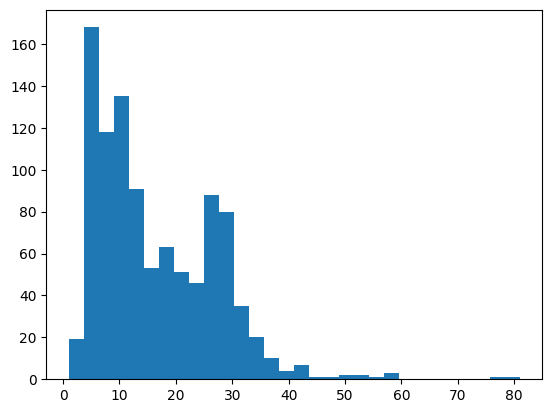

max_length: 30


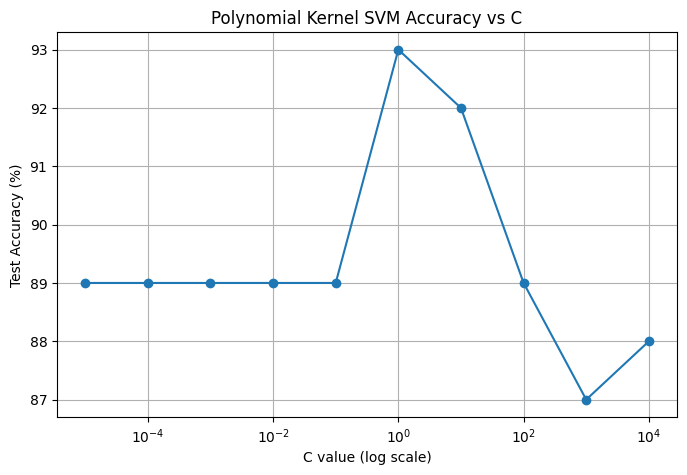

Test Accuracy with C based on minimum train accuracy: 87.00%


In [24]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# 1. 문장 길이 확인 및 padding
x_lengths = [len(seq) for seq in indexing_x_data]
plt.hist(x_lengths, bins=30)
plt.show()
max_length = int(np.percentile(x_lengths, 90))
print("max_length:", max_length)

for index in range(len(indexing_x_data)):
    length = len(indexing_x_data[index])
    if length > max_length:
        indexing_x_data[index] = indexing_x_data[index][:max_length]
    elif length < max_length:
        indexing_x_data[index] += [0]*(max_length-length)

# 2. train/test split
number_of_train = int(len(indexing_x_data)*0.9)
train_x = indexing_x_data[:number_of_train]
train_y = indexing_y_data[:number_of_train]
test_x = indexing_x_data[number_of_train:]
test_y = indexing_y_data[number_of_train:]
original_test_x = indexing_x_data[number_of_train:]

# 3. train 데이터 기준 단어 score 계산
index_score = {}
for i in range(len(train_x)):
    seq = train_x[i]
    label = train_y[i]  # 0: spam, 1: ham
    for idx in seq:
        if idx == 0: continue
        if idx not in index_score:
            index_score[idx] = 0
        index_score[idx] += 1 if label==1 else -1

# 4️. train_x, test_x를 기존 {단어:인덱스} -> {인덱스:빈도수} 형태로 변환
for i in range(len(train_x)):
    seq = train_x[i]
    train_x[i] = [0 if idx==0 else index_score.get(idx,0) for idx in seq]

for i in range(len(test_x)):
    seq = test_x[i]
    test_x[i] = [0 if idx==0 else index_score.get(idx,0) for idx in seq]

# 5. 정규화
train_x = np.array(train_x)
test_x = np.array(test_x)
train_x = train_x / (np.max(np.abs(train_x), axis=1, keepdims=True) + 1e-6)
test_x = test_x / (np.max(np.abs(test_x), axis=1, keepdims=True) + 1e-6)

# 6. 여러 C 값 실험 및 시각화 | 최적 C 모델 선정
C_values = [10**-5,10**-4,10**-3, 10**-2, 10**-1,
            10**0, 10**1, 10**2,10**3,10**4]
accuracies = []

for C in C_values:
    svm = SVC(kernel='poly', degree=2, C=C)
    svm.fit(train_x, train_y)
    predict = svm.predict(test_x)
    acc = 100.0 * np.sum(predict == test_y) / len(test_y)
    accuracies.append(acc)


plt.figure(figsize=(8,5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Test Accuracy (%)')
plt.title('Polynomial Kernel SVM Accuracy vs C')
plt.grid(True)
plt.show()

# 최소 accuracy를 내는 C 선택
worst_index = np.argmin(accuracies)
worst_C = C_values[worst_index]

# 선택한 C로 최종 모델 학습
best_svm = SVC(kernel='poly', degree=2, C=worst_C)
best_svm.fit(train_x, train_y)

# 예측
predict = best_svm.predict(test_x)
correct_count = np.sum(predict == test_y)
accuracy = 100.0 * correct_count / len(test_y)
print("Test Accuracy with C based on minimum train accuracy: {:.2f}%".format(accuracy))


<h2>SVM 모델을 이용한 평가</h2>

<pre>


<b>1. svm.predict(real_test_score) 함수를 사용하여 SVM 모델을 이용하여 평가</b>
  
  svm.predict(real_test_score)
  args
    real_test_score : {단어 인덱스: 단어 점수(학습에 미포함)} 구조의 딕셔너리
    데이터셋. 처음 뽑고 사용하지 않은 실제 테스트 데이터셋을 전처리하여 만들었다.
  return :
    입력 문장들에 대한 모델의 출력 라벨 리스트
    
<b>2. 성능 측정</b>
  정답 라벨과 모델의 출력 라벨을 비교하여 성능 측정
  
<b>3. tokenizer.sequences_to_texts(data) 함수를 이용하여 indexing 된 데이터를 단어로 치환</b>

  tokenizer.sequences_to_texts(data)
  args
    data : indexing 된 리스트
  return :
    단어로 치환된 리스트
    
  예시)
    [38, 93, 239, 240, 241, 242, 53, 11, 243, 72, 94, 244, 245, 126, 246, 247, 73, 74, 248, 127] -> Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    
<b>4. 입력 문장에 대한 모델의 출력과 정답 출력</b>

  처음 보는 데이터셋의 경우에도 70%~80% 정도의 정확도를 뽑아내는 것을
  확인할 수 있었다.

</pre>

In [25]:


#위 train_x와 test_x 처럼 동일하게 전처리 진행
real_test_indexed = tokenizer.texts_to_sequences(real_test_x)

real_test_score = []
for seq in real_test_indexed:
    new_seq = [0 if idx==0 else index_score.get(idx,0) for idx in seq]
    real_test_score.append(new_seq)

for i in range(len(real_test_score)):
    length = len(real_test_score[i])
    if length > max_length:
        real_test_score[i] = real_test_score[i][:max_length]
    elif length < max_length:
        real_test_score[i] += [0]*(max_length - length)

for i in range(len(real_test_score)):
    length = len(real_test_score[i])
    if length > max_length:
        real_test_score[i] = real_test_score[i][:max_length]
    elif length < max_length:
        real_test_score[i] += [0]*(max_length - length)


# 최적 모델에 테스트 데이터 넣고 결과 출력
predict = best_svm.predict(real_test_score)
correct_count = 0
for index in range(len(predict)):
  if(test_y[index] == predict[index]):
    correct_count += 1

accuracy = 100.0*correct_count/len(test_y)


print("실전 테스트 Accuracy: " + str(accuracy))

#index를 다시 word로 바꾸는 과정
index2label = {0:"spam", 1:"ham"}

# 위와 동일
test_x_word = tokenizer.sequences_to_texts(original_test_x)

for index in range(len(test_x_word)):
  print()
  print("문장 : ", test_x_word[index])
  print("정답 : ", index2label[test_y[index]])
  print("모델 출력 : ", index2label[predict[index]])

실전 테스트 Accuracy: 78.0

문장 :  your free ringtone is waiting to be collected simply text the password mix to 85069 to verify get usher and britney fml po box 5249 mk17 92h 450ppw 16
정답 :  spam
모델 출력 :  ham

문장 :  probably money worries things are coming due and i have several outstanding invoices for work i did two and three months ago
정답 :  ham
모델 출력 :  ham

문장 :  how is it possible to teach you and where
정답 :  ham
모델 출력 :  spam

문장 :  i wonder if your phone battery went dead i had to tell you i love you babe
정답 :  ham
모델 출력 :  ham

문장 :  lovely smell on this bus and it ain't tobacco
정답 :  ham
모델 출력 :  ham

문장 :  we're all getting worried over here derek and taylor have already assumed the worst
정답 :  ham
모델 출력 :  ham

문장 :  hey what's up charles sorry about the late reply
정답 :  ham
모델 출력 :  ham

문장 :  all the lastest from stereophonics marley dizzee racal libertines and the strokes win nookii games with flirt click themob wap bookmark or text wap to 82468
정답 :  spam
모델 출력 :  spam

문장 :